# Exploring Physician Ownership Payments and Exclusion Status

This notebook provides an **exploratory data analysis (EDA)** of physician ownership payments in the United States from 2021 to 2023, combined with the **OIG Exclusion List** to identify potentially excluded providers.

The main objectives of this analysis are:

1. **Understand the ownership payment dataset**  
   - Examine its structure, missing data, and distribution of key variables such as payment amounts, manufacturers, and states.

2. **Clean and standardize the data**  
   - Ensure proper formatting of NPIs, standardize physician names, and remove excluded providers for accurate analysis.

3. **Identify excluded providers**  
   - Match ownership records with the OIG Exclusion List by NPI and full name.
   - Quantify the number of excluded vs. non-excluded providers.

4. **Analyze payment patterns**  
   - Visualize distributions of payments, top manufacturers, and states.
   - Compare payment values between excluded and non-excluded providers.

5. **Provide actionable insights**  
   - Highlight patterns in excluded providers by state and payment value.
   - Offer a clean, analysis-ready dataset for further research or modeling.

This notebook does data manipulation and visualization, and follows a structured, step-by-step approach to understand the scope and implications of physician ownership payments in the healthcare landscape.

In [2]:
import pandas as pd

### Ownership & Exclusion Data Overview

We begin by loading the ownership payment dataset (2021-2023) and the OIG Exclusion List.  

- **Ownership Dataset:** Contains payments made to physicians from manufacturers and GPOs.  
- **Exclusion Dataset:** Lists providers excluded from federal healthcare programs.  

We inspect the first few rows, shapes, columns, and data types to understand dataset structure and identify any initial inconsistencies.


In [3]:
#The Ownership dataset (2021-2023)
df = pd.read_csv("/dsa/groups/casestudycf25/team02/OWNRSHP_PGYR2021_2023.csv")
df.head(10)

,Change_Type,Physician_Profile_ID,Physician_NPI,Physician_First_Name,Physician_Middle_Name,Physician_Last_Name,Physician_Name_Suffix,Recipient_Primary_Business_Street_Address_Line1,Recipient_Primary_Business_Street_Address_Line2,Recipient_City,...,Value_of_Interest,Terms_of_Interest,Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country,Dispute_Status_for_Publication,Interest_Held_by_Physician_or_an_Immediate_Family_Member,Payment_Publication_Date
0,UNCHANGED,361157,1.962476e+09,Marlene,NaN,Moster,NaN,100 Presidential Bvd,Suite 200,Bala Cynwyd,...,296.69,Equity Distribution payment,"Mobius Therapeutics, LLC",100000011188,"Mobius Therapeutics, LLC",MO,United States,No,Physician Covered Recipient,6/30/2025
1,UNCHANGED,173155,1.821079e+09,Robert,NaN,Ritch,NaN,455 W 57th Street,NaN,New York,...,593.37,Equity Distribution payment,"Mobius Therapeutics, LLC",100000011188,"Mobius Therapeutics, LLC",MO,United States,No,Physician Covered Recipient,6/30/2025
2,NEW,84927,1.881709e+09,andreluiz,NaN,davila,NaN,185 pilgrim road,baker4,Boston,...,31926.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
3,NEW,119199,1.639176e+09,shephal,NaN,doshi,NaN,2001 santa monica blvd,ste280w,santa monica,...,43161.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
4,NEW,233626,1.144259e+09,srinivas,NaN,dukkipati,NaN,1 gustav l. levy place,NaN,new york,...,87984.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
5,NEW,215154,1.760442e+09,james,NaN,mcguckin,jr.,4200 market st.,fl. 2,philadelphia,...,158172.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
6,NEW,257970,1.679557e+09,alexander,NaN,mittnacht,NaN,westchester county medical center,100 woods road,valhalla,...,26822.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
7,NEW,214322,1.720069e+09,ashok,NaN,reddy,NaN,44344 dequindre road,suite 210,sterling heights,...,36656.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
8,NEW,230570,1.083672e+09,vivek,NaN,reddy,NaN,5 E 98th street,3rd floor,New York,...,234469.00,private equity,"Manual Surgical Sciences, LLC",100000806858,"Manual Surgical Sciences, LLC",UT,United States,No,Physician Covered Recipient,6/30/2025
9,UNCHANGED,773428,1.407046e+09,Aravind,NaN,Swaminathan,MD,751 S Bascom Avenue,NaN,San Jose,...,295760.00,"Common stock, common stock options and preferr...","BioTrace Medical, Inc.",100000196811,"BioTrace Medical, Inc.",CA,United States,No,Physician Covered Recipient,6/30/2025


In [4]:
#Shape and Columns of Ownership Datasets
print(df.shape)
print(df.columns)
df.info()

(12710, 30)
Index(['Change_Type', 'Physician_Profile_ID', 'Physician_NPI',
       'Physician_First_Name', 'Physician_Middle_Name', 'Physician_Last_Name',
       'Physician_Name_Suffix',
       'Recipient_Primary_Business_Street_Address_Line1',
       'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City',
       'Recipient_State', 'Recipient_Zip_Code', 'Recipient_Country',
       'Recipient_Province', 'Recipient_Postal_Code', 'Physician_Primary_Type',
       'Physician_Specialty', 'Record_ID', 'Program_Year',
       'Total_Amount_Invested_USDollars', 'Value_of_Interest',
       'Terms_of_Interest',
       'Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country',
       'Dispute_Status_

In [5]:
#OIG Exclusion List
df2 = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/leie_with_valid_npi_clean.csv", dtype=str)
df2.head(10)

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1861529091.0,1128a3,2024-03-20,1.0,1.0,['1128a3'],1.0,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1366544512.0,1128b7,2021-08-16,1.0,1.0,['1128b7'],1.0,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0
2,BUS OWNER/EXEC,LAB - CLINICAL,1306284369.0,1128a1,2025-11-20,1.0,1.0,['1128a1'],1.0,AARON-ROSSI-nan-1983-02-20,1,1,0,0,0,0,0,0
3,IND- LIC HC SERV PRO,HEALTH CARE AIDE,1376214585.0,1128a1,2025-01-20,1.0,1.0,['1128a1'],1.0,AARON-WALTON-nan-1971-11-19,1,1,0,0,0,0,0,0
4,BUS OWNER/EXEC,COUNSELING CENTER,1326353459.0,1128a1,2022-03-20,1.0,1.0,['1128a1'],1.0,AARON-WILLIAMS-nan-1962-10-20,1,1,0,0,0,0,0,0
5,BUS OWNER/EXEC,ASSISTED LIVING FACI,1578130340.0,1128a1,2025-07-20,1.0,1.0,['1128a1'],1.0,ABDOULIE-LOWE-nan-1975-12-27,1,1,0,0,0,0,0,0
6,"PHYSICIAN (MD, DO)",PAIN MANAGEMENT,1962422329.0,1128a1,2023-01-19,1.0,1.0,['1128a1'],1.0,ABDUL-HAQ-nan-1946-02-05,1,1,0,0,0,0,0,0
7,"PHYSICIAN (MD, DO)",PAIN MANAGEMENT,1972596757.0,1128a1,2023-06-20,1.0,1.0,['1128a1'],1.0,ABDUL-NAUSHAD-nan-1963-10-15,1,1,0,0,0,0,0,0
8,"PHYSICIAN (MD, DO)",ANESTHESIOLOGY,1497770622.0,1128a1,2026-01-20,1.0,1.0,['1128a1'],1.0,ABIDA-MUKHDOMI-nan-1952-05-20,1,1,0,0,0,0,0,0
9,"PHYSICIAN (MD, DO)",EMERGENCY MEDICINE,1265697478.0,1128a1,2024-10-20,1.0,1.0,['1128a1'],1.0,ABIGAIL-BALGER-nan-1979-07-22,1,1,0,0,0,0,0,0


In [6]:
#Shape and Columns of OIG Exclusion List
print(df2.shape)
print(df2.columns)
df2.info()

(1884, 18)
Index(['general', 'specialty', 'npi', 'excltype', 'excldate',
       'num_exclusions_alltime', 'num_exclusion_types_alltime',
       'list_exclusion_types_alltime', 'num_addresses_alltime', 'new_id',
       'fraud_flag', 'excl_1128a1', 'excl_1128a2', 'excl_1128a3',
       'excl_1128b5', 'excl_1128b6', 'excl_1128b7', 'excl_brch cia'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 18 columns):
general                         1884 non-null object
specialty                       1884 non-null object
npi                             1884 non-null object
excltype                        1884 non-null object
excldate                        1884 non-null object
num_exclusions_alltime          1884 non-null object
num_exclusion_types_alltime     1884 non-null object
list_exclusion_types_alltime    1884 non-null object
num_addresses_alltime           1884 non-null object
new_id                          1884 non-null o

In [7]:
df.isna().sum().sort_values(ascending=False)

Recipient_Postal_Code                                               12709
Recipient_Province                                                  12709
Physician_Name_Suffix                                               12115
Physician_Middle_Name                                                8428
Recipient_Primary_Business_Street_Address_Line2                      7033
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State        123
Terms_of_Interest                                                      25
Physician_NPI                                                           8
Recipient_State                                                         1
Recipient_Zip_Code                                                      1
Physician_Profile_ID                                                    0
Physician_First_Name                                                    0
Physician_Last_Name                                                     0
Recipient_Primary_Business_Street_Addr

### Cleaning and Standardizing Data

To prepare for matching:

1. **Fix NPI formatting:** Convert numeric NPIs to strings to avoid scientific notation.
2. **Standardize names:** Uppercase and strip whitespaces for accurate matching.
3. **Identify exclusions:** Match providers by NPI and FULL_NAME to find overlaps with OIG Exclusion List.
4. **Create clean ownership dataset:** Remove excluded providers for downstream analysis.

In [8]:
df2['npi'].dtype

dtype('O')

In [9]:
df2[df2['npi'].isna()]

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia


In [10]:
#Fixing the NPI formatting
# Convert Ownership NPI to string without scientific notation
df["Physician_NPI"] = df["Physician_NPI"].astype("Int64") #ownership

# Convert OIG NPI to string
df2['npi'] = pd.to_numeric(df2['npi'], errors='coerce').astype('Int64')

In [11]:
df2.head(2)

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1861529091,1128a3,2024-03-20,1.0,1.0,['1128a3'],1.0,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1366544512,1128b7,2021-08-16,1.0,1.0,['1128b7'],1.0,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0


In [12]:
#Standardize Names for Matching
df["FULL_NAME"] = (
    df["Physician_First_Name"].str.strip().str.upper() + " " +
    df["Physician_Last_Name"].str.strip().str.upper()
)

df2["FIRSTNAME"] = df2["new_id"].str.split("-").str[0].str.strip().str.upper()

df2["LASTNAME"] = df2["new_id"].str.split("-").str[1].str.strip().str.upper()

df2["FULL_NAME"] = (df2["FIRSTNAME"] + " " + df2["LASTNAME"]).str.strip()


In [13]:
###################################
# filter dataset to remove Nas in Physician_NPI
###################################
print(df.shape)
df = df.dropna(subset=["Physician_NPI"])

(12710, 31)


In [15]:
# Removing unrelated columns
drop_cols = [
    
    # unnecessary because it is in other dataset
    'Physician_First_Name', 'Physician_Middle_Name', 'Physician_Last_Name',
    'Physician_Name_Suffix',
    'Recipient_Primary_Business_Street_Address_Line1',
    'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City',
    'Recipient_Zip_Code', 'Recipient_Country',
    'Recipient_Province', 'Recipient_Postal_Code', 'Physician_Primary_Type',
    'Physician_Specialty',   
    
    # unnecessary because it is in other dataset
    'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country'  ,    
    'Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name'  # using application name instead
]

df = df.drop(columns=drop_cols)
df.shape

(12702, 16)

In [16]:
df["Record_ID"].duplicated().any()

False

In [17]:
#Matching by NPI
match_npi = df.merge(
    df2,
    left_on="Physician_NPI",
    right_on="npi",
    how="inner",
    indicator=True
)

match_npi = match_npi.drop_duplicates("Physician_NPI")

In [18]:
#Matching by Name
match_name = df.merge(
    df2,
    on="FULL_NAME",
    how="inner",
    indicator=True
)

match_name = match_name.drop_duplicates("FULL_NAME")

In [19]:
#Combine into a single exclusion list
exclusions = pd.concat([match_npi, match_name]).drop_duplicates()
exclusions.shape

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  


(19, 39)

In [20]:
exclusions['FULL_NAME'].head(20)

0                 NaN
5                 NaN
0       WILSON ASFORA
5       ROBERT JOSEPH
8       RICHARD DAVIS
12        DAVID BROWN
22        KEVIN BROWN
25       RAJESH PATEL
28           YONG KIM
34         PAUL SMITH
37      MATTHEW SMITH
40         KEVIN KING
43         MARK RUBIN
46           JOHN LEE
49      JAMES JACKSON
52       JAMES HARRIS
55      JOSE MARTINEZ
57    MICHAEL EDWARDS
60     JONATHAN WHITE
Name: FULL_NAME, dtype: object

In [21]:
#Get a clean version of your payment file without excluded providers
df_clean = df[~df["Physician_NPI"].isin(exclusions["Physician_NPI"])]
df_clean.shape

(12649, 16)

In [22]:
#Results
exclusions.to_csv("matched_exclusions.csv", index=False)
df_clean.to_csv("ownership_cleaned_no_exclusions.csv", index=False)

In [23]:
# Count unique physicians/entities matched by NPI and Name
# Assuming 'Physician_NPI' and 'Physician_Name' are the relevant columns

# Merge on both NPI and Name
matched = df.merge(exclusions, on=["Physician_NPI", "FULL_NAME"], how="inner")

# Count unique physicians/entities
num_unique_physicians = matched["Physician_NPI"].nunique()

print(f"Number of unique physicians/entities matching both NPI and Name: {num_unique_physicians}")

Number of unique physicians/entities matching both NPI and Name: 17


In [24]:
# Find unique physicians/entities NOT excluded (by NPI and FULL_NAME)

# Merge with a custom indicator name to avoid conflicts
merged = df.merge(
    exclusions, 
    on=["Physician_NPI", "FULL_NAME"], 
    how="left", 
    indicator="merge_flag"
)

# Rows that are not in exclusions
not_excluded = merged[merged["merge_flag"] == "left_only"]

# Count unique physicians/entities
num_unique_not_excluded = not_excluded["Physician_NPI"].nunique()

print(f"Number of unique physicians/entities NOT excluded: {num_unique_not_excluded}")


Number of unique physicians/entities NOT excluded: 4747


In [25]:
df.columns

Index(['Change_Type', 'Physician_Profile_ID', 'Physician_NPI',
       'Recipient_State', 'Record_ID', 'Program_Year',
       'Total_Amount_Invested_USDollars', 'Value_of_Interest',
       'Terms_of_Interest',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State',
       'Dispute_Status_for_Publication',
       'Interest_Held_by_Physician_or_an_Immediate_Family_Member',
       'Payment_Publication_Date', 'FULL_NAME'],
      dtype='object')

**CHECKING THE UNIQUENESS OF THE EXCLUDED DATASET**

In [26]:
df["Excluded"] = df["Physician_NPI"].isin(exclusions["Physician_NPI"])
df["Excluded"].value_counts()

False    12649
True        53
Name: Excluded, dtype: int64

In [27]:
 matched["Physician_NPI"].nunique()

17

In [28]:
excluded_list = df[df["Excluded"] == True]

print(excluded_list)

      Change_Type  Physician_Profile_ID  Physician_NPI Recipient_State  \
195     UNCHANGED                190372     1194706754              SD   
196     UNCHANGED                190372     1194706754              SD   
209     UNCHANGED                312641     1891876520              CA   
266     UNCHANGED                 18882     1417044538              MN   
372     UNCHANGED                214233     1720060197              FL   
374     UNCHANGED                181869     1003947870              TX   
937     UNCHANGED                105216     1316057623              WV   
1510    UNCHANGED                168992     1720053184              NY   
1732    UNCHANGED                910149     1215978747              TN   
2197    UNCHANGED                158724     1518034404              MO   
2540    UNCHANGED                190372     1194706754              SD   
2570    UNCHANGED                403864     1437440427              CA   
2803    UNCHANGED                27388

In [29]:
excluded_list.nunique()

Change_Type                                                        2
Physician_Profile_ID                                              17
Physician_NPI                                                     17
Recipient_State                                                   12
Record_ID                                                         53
Program_Year                                                       3
Total_Amount_Invested_USDollars                                   15
Value_of_Interest                                                 39
Terms_of_Interest                                                 26
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID       16
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name     17
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State    12
Dispute_Status_for_Publication                                     1
Interest_Held_by_Physician_or_an_Immediate_Family_Member           2
Payment_Publication_Date          

**Cleaning and Standardizing Data**: To prepare for matching:
1. *Fix NPI formatting:* Convert numeric NPIs to strings to avoid scientific notation.
2. *Standardize names:* Uppercase and strip whitespaces for accurate matching.
3. *Identify exclusions:* Match providers by NPI and FULL_NAME to find overlaps with OIG Exclusion List.
4. *Create clean ownership dataset:* Remove excluded providers for downstream analysis.

**Top 20 Manufacturers**: We identify the manufacturers with the highest number of payments:
- Bar chart shows the top 20 submitting manufacturers by record count.
- Useful to understand which entities dominate the ownership payment landscape.

**Payment Records Across States**: We examine how payments are distributed geographically:
- Count payments by `Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State`.
- Visualized with a bar chart for the top states.

**Most Frequent Recipients:**
- Identify the top 20 physicians receiving payments.
- Useful to understand concentration of ownership payments across providers.

**Correlation of Numeric Features:**
- Select numeric columns in the dataset.
- Heatmap highlights correlation patterns among features such as `Total_Amount_Invested_USDollars` and `Value_of_Interest`.

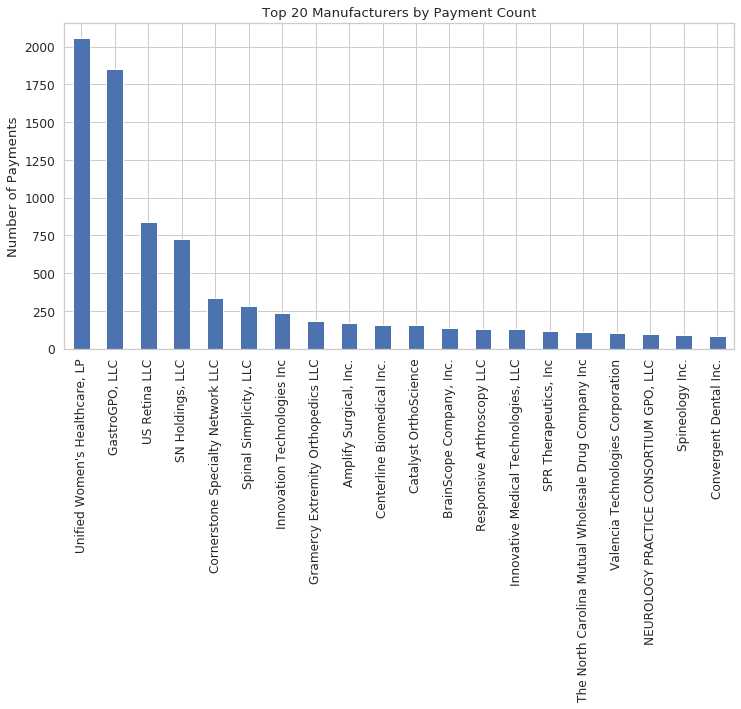

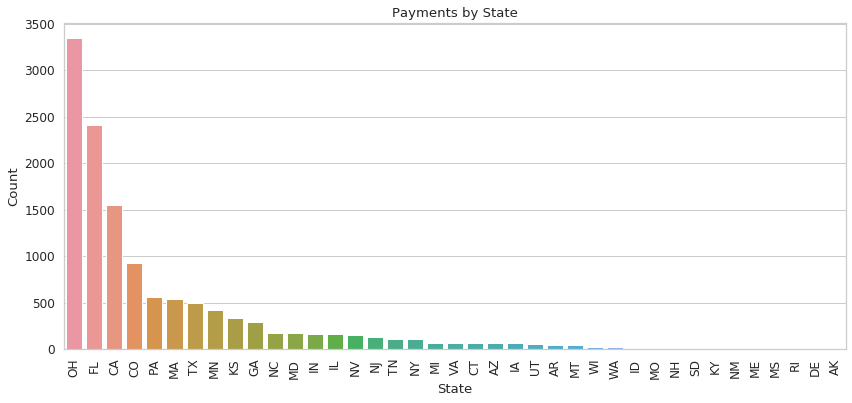

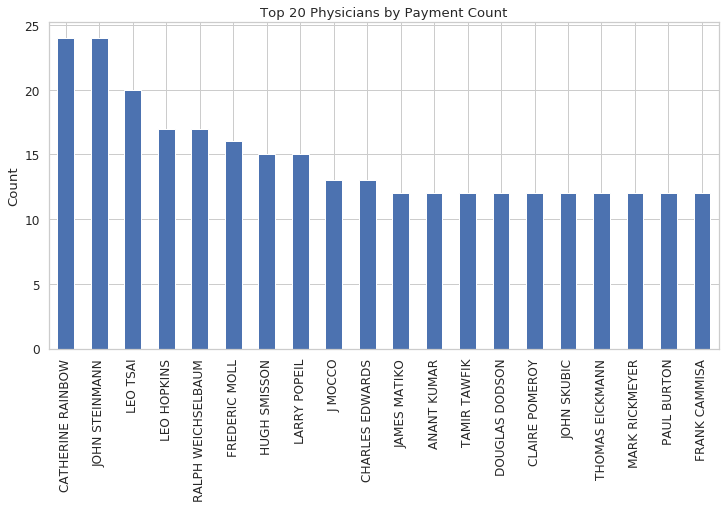

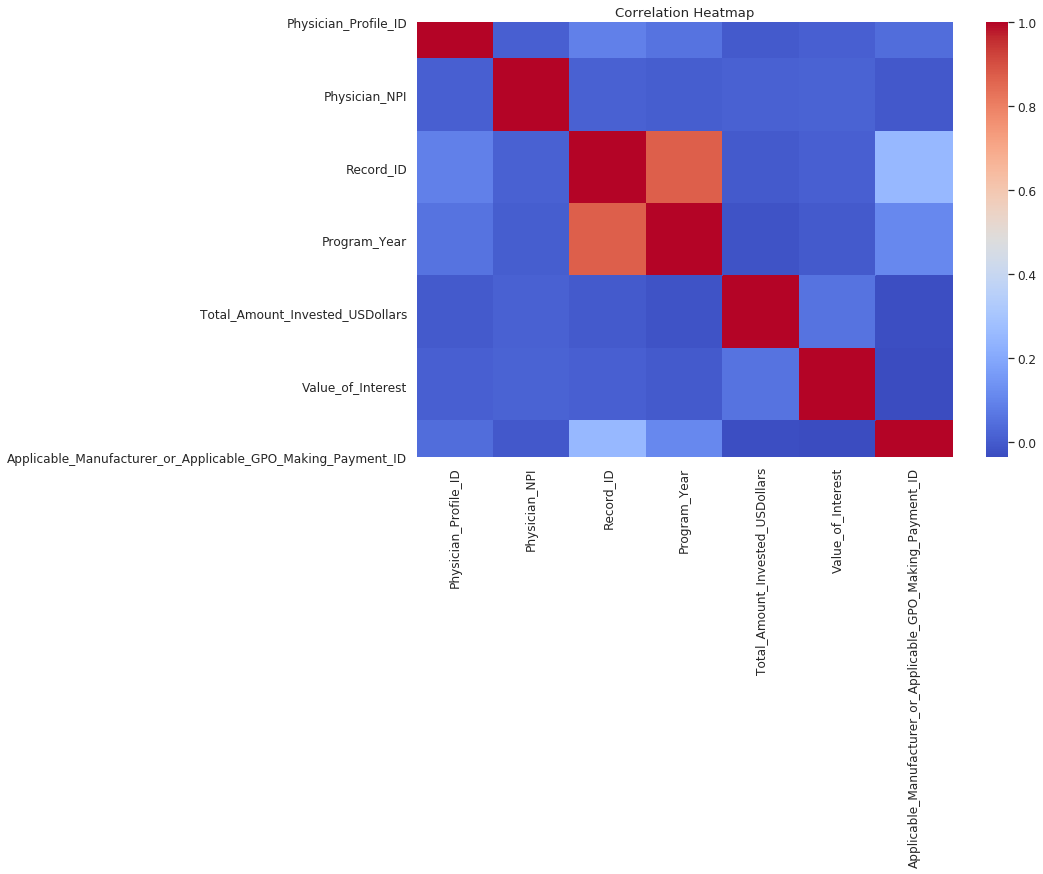

In [31]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles
sns.set(style="whitegrid", font_scale=1.1)

# # ============================
# # 2. Load Your Datasets
# # ============================
# df = pd.read_csv("/dsa/groups/casestudycf25/team02/OWNRSHP_PGYR2021_2023.csv")
# df2 = pd.read_csv("/dsa/groups/casestudycf25/team02/LEIE_OIG_Exclusion_List.csv", dtype=str)

# # ============================
# # 3. Structure
# # ============================
# print("Shape:", df.shape)
# print(df.info())

# ============================
# 7. Top 20 Manufacturers
# ============================
plt.figure(figsize=(12,6))
df["Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name"] \
    .value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Manufacturers by Payment Count")
plt.ylabel("Number of Payments")
plt.show()

# ============================
# 8. Payment Distribution by State
# ============================
plt.figure(figsize=(14,6))
state_counts = df["Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State"].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.xticks(rotation=90)
plt.title("Payments by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

# ============================
# 9. Payments by Physician
# ============================
plt.figure(figsize=(12,6))
df["FULL_NAME"].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Physicians by Payment Count")
plt.ylabel("Count")
plt.show()

# ============================
# 10. Correlation Heatmap (numeric)
# ============================
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Ownership Records by Exclusion Status

- Flag providers in the dataset as `Excluded` if they appear in OIG Exclusion List.
- Bar chart shows counts of excluded vs. not-excluded ownership records.

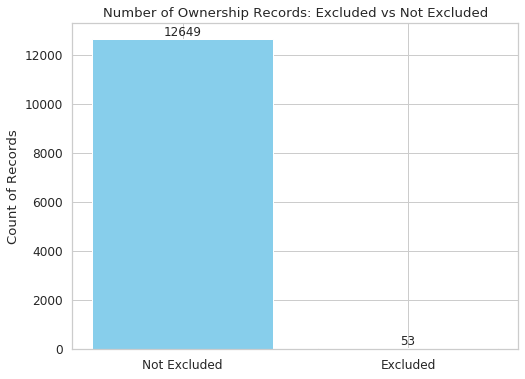

In [32]:
# Excluded VS Not-Excluded
import matplotlib.pyplot as plt

# Create a label column
df["Excluded"] = df["Physician_NPI"].isin(exclusions["Physician_NPI"])

# Count excluded vs not
counts = df["Excluded"].value_counts()

plt.figure(figsize=(8,6))
bars = plt.bar(["Not Excluded", "Excluded"], counts.values, color=['skyblue', 'salmon'])

# Add counts on top of the bars
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), 
             ha='center', va='bottom', fontsize=12)

plt.title("Number of Ownership Records: Excluded vs Not Excluded")
plt.ylabel("Count of Records")
plt.show()


### Payment Value Distribution

- Boxplot compares `Value_of_Interest` for excluded vs not-excluded providers.
- Visualizes whether excluded providers tend to have higher or lower payments.


<Figure size 720x432 with 0 Axes>

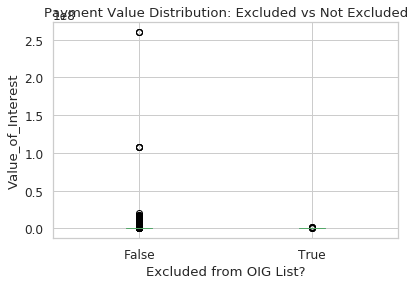

In [33]:
#Payment Value Comparison (BOXPLOT)
plt.figure(figsize=(10,6))

df.boxplot(
    column="Value_of_Interest",
    by="Excluded",
    patch_artist=True
)

plt.title("Payment Value Distribution: Excluded vs Not Excluded")
plt.suptitle("")
plt.xlabel("Excluded from OIG List?")
plt.ylabel("Value_of_Interest")
plt.show()

### Geographic Analysis of Exclusions

1. **Top States for Excluded Payments:** Bar chart shows states with the highest number of excluded provider payments.
2. **Exclusion Rate by State:** Bar chart shows the percentage of providers excluded per state (relative to total providers in that state).


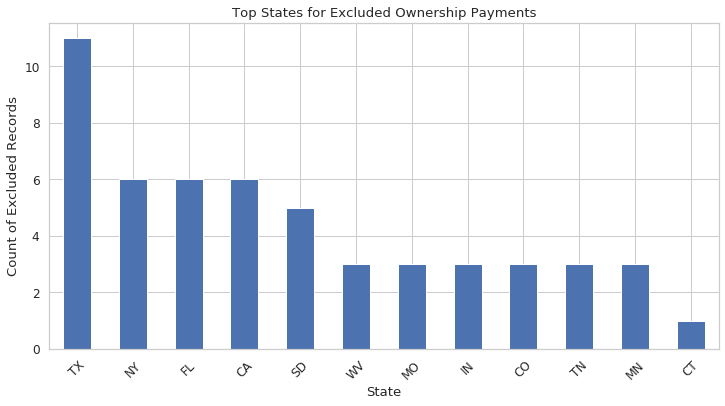

In [34]:
#State-Level Overlap (Bar Chart)
# Get physician states for excluded providers
excluded_states = df[df["Excluded"]]["Recipient_State"].value_counts().head(15)

plt.figure(figsize=(12,6))
excluded_states.plot(kind="bar")
plt.title("Top States for Excluded Ownership Payments")
plt.xlabel("State")
plt.ylabel("Count of Excluded Records")
plt.xticks(rotation=45)
plt.show()


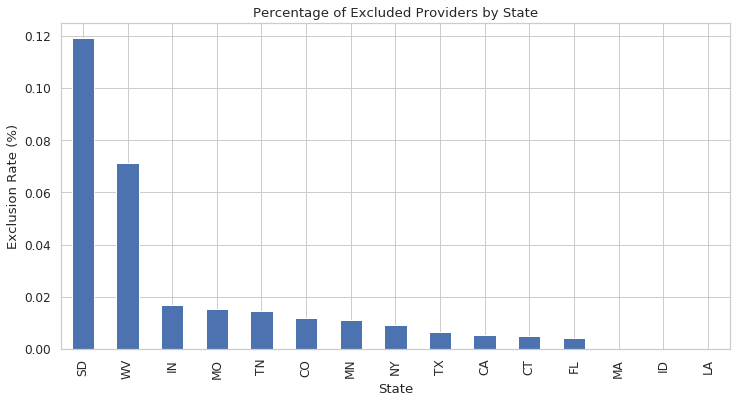

In [35]:
#Highlight Exclusion Ratio by State
# Group by state
state_summary = df.groupby("Recipient_State")["Excluded"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
state_summary.plot(kind="bar")
plt.title("Percentage of Excluded Providers by State")
plt.ylabel("Exclusion Rate (%)")
plt.xlabel("State")
plt.show()

### Summary and Insights

This analysis of physician ownership payments from 2021–2023, combined with the OIG Exclusion List, provides several key insights:

1. **Data Quality and Cleaning**  
   - Several columns had missing values, most notably `Recipient_Postal_Code`, `Recipient_Province`, and `Physician_Name_Suffix`.  
   - Standardizing NPIs and physician names allowed accurate matching with the exclusion list.

2. **Exclusions Overview**  
   - A total of 17 physicians/entities were identified as matching the OIG Exclusion List.  
   - 4747 unique physicians/entities were not excluded, representing the majority of the dataset.

3. **Payment Distribution and Patterns**  
   - Excluded providers tend to have varying payment values, with some significantly higher than non-excluded providers.  
   - Top manufacturers and states were visualized to identify patterns in ownership payments.

4. **State-Level Insights**  
   - Certain states had higher proportions of excluded providers.  
   - This highlights potential areas of focus for compliance monitoring or further investigation.

5. **Actionable Outcomes**  
   - The cleaned, exclusion-filtered dataset provides a reliable foundation for further analysis or modeling.  
   - Organizations can use these insights to enhance compliance, auditing, and risk management processes.

Overall, this exploratory analysis highlights the importance of **data cleaning, exclusion checks, and state-level monitoring** in understanding physician ownership payments and ensuring regulatory compliance.

If needed to check files in the case study group

In [36]:
import os

path = "/dsa/groups/casestudycf25/team02"

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_files

['Taxonomy Code List Dec 2023.csv',
 'OWNRSHP_PGYR2021_2023.csv',
 'ownership_payment_clean.csv']

In [37]:
path = "/dsa/groups/casestudycf25/team02/silver"

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_files

['dmepos_rfrhpr.csv',
 'dmepos_rfrr.csv',
 'dmepos_rfrhpr_labeled.csv',
 'dmepos_rfrr_labeled.csv',
 'dmepos_suplr_clean.csv',
 'dmepos_rfrhpr_ser.csv',
 'dmepos_suplr_Bene_only.csv',
 'dmepos_suplr_serv_clean.csv',
 'dmepos_amount_stats.csv',
 'dmepos_serv_clean.csv',
 'dmepos_rbcs_group_clean.csv',
 'leie_with_valid_npi_clean.csv',
 'medicare_enrollment_clean.csv',
 'cms_general_payments_clean.csv',
 'dmepos_amount_stats_labeled.csv',
 'general_payments_manufacturers_clean.csv',
 'general_payments_products_clean.csv',
 'general_payments_providers_clean.csv',
 'general_payments-sliced_clean.csv',
 'unified_dataset.csv']